In [1]:
# GLiNER Taxonomy Tuning Notebook
# 
# This notebook explores GLiNER pollution detection on SOBR data:
# 1. Load sample posts from SOBR
# 2. Run GLiNER with different taxonomy configurations
# 3. Visualize detected span distribution
# 4. Calculate "Explicit Recall" against regex baselines

import sys
sys.path.append('..')

In [ ]:
# Import dependencies
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import numpy as np

from neuro_stylometry.phase_a_pipeline import PhaseAPipeline
from neuro_stylometry.factories.strategy_factory import StrategyFactory
from neuro_stylometry.pollution_guard.explicit_recall import compute_explicit_recall
from neuro_stylometry.data_engine.dataset import SOBRDataset

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Initialize pipeline with strict YAML config authority (new API)
strategy = StrategyFactory.create_filter_strategy()
pipeline = PhaseAPipeline.from_yaml(strategy=strategy, mode="laptop")

# Access components via facade methods
detector = pipeline.get_detector()
masker = pipeline.get_masker()

print("=" * 60)
print("GLINER CONFIGURATION")
print("=" * 60)
print(f"GLiNER model: {detector.model_name}")
print(f"GLiNER device: {detector.device}")
print(f"GLiNER max_length: {detector.max_length}")
print(f"Confidence threshold: {detector.confidence_threshold}")
print(f"Target labels: {len(detector.taxonomy.get_target_labels())}")
print(f"Distractor labels: {len(detector.taxonomy.distractor_labels)}")
print("=" * 60)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\transformers\convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: http

GLiNER device: cuda
GLiNER confidence_threshold: 0.85
Target labels: 10
Distractor labels: 5


## 1. Load SOBR Sample Data

Load a sample of posts from the SOBR laptop dataset for experimentation.

In [3]:
# Load SOBR dataset
dataset_path = Path("../artifacts/data/sobr_laptop.arrow")
dataset = SOBRDataset(arrow_path=dataset_path, seed=42)

# Take a sample of 100 posts
sample_size = 100
table = dataset.table.slice(0, sample_size)
posts = table["post"].to_pylist()
post_ids = table["post_id"].to_pylist()

print(f"Loaded {len(posts)} sample posts")
print(f"\nExample post:\n{posts[0][:500]}...")

Loaded 100 sample posts

Example post:
came to be. I believe the "pushback" when a film shows a character of color is mostly fabricated by production companies in order to get cheap publicity. Marketing people on social media with alt accounts publishing "memes" the same moment a trailer comes out (for and against) to create astroturfed polemic, so now their shitty flick with a predictable plot that has nothing to say it's suddenly trending and a cultural icon. Strategy is a specific genre in gaming. All games require strategizing in...


## 2. Initialize GLiNER Detector

Initialize GLiNER with SOBR-specific taxonomy.

In [ ]:
# Detector and masker are created via the Phase A facade above
taxonomy = detector.taxonomy

print("=" * 60)
print("TAXONOMY DETAILS")
print("=" * 60)
print(f"Target labels: {len(taxonomy.get_target_labels())}")
print(f"  {taxonomy.get_target_labels()[:5]}...")
print(f"\nDistractor labels: {len(taxonomy.distractor_labels)}")
print(f"  {taxonomy.distractor_labels[:5]}...")
print(f"\nMask tokens (examples): {list(taxonomy.get_mask_tokens().items())[:3]}")
print("=" * 60)



Target labels: 10
Distractor labels: 5
Example mask tokens: [('age_statement', '[MASK:AGE]'), ('birth_year_statement', '[MASK:BIRTH_YEAR]'), ('gender_indicator', '[MASK:GENDER]')]


## 3. Run Pollution Detection

Detect pollution spans in sample posts.

In [5]:
# Detect pollution spans (batch size sourced from YAML config)
print("Detecting pollution spans...")
gliner_batch_size = int(pipeline.config["gliner"]["batch_size"])
entities_batch = detector.detect_spans_long(posts, batch_size=gliner_batch_size, show_progress=True)

# Count total detections
total_detections = sum(len(entities) for entities in entities_batch)
posts_with_detections = sum(1 for entities in entities_batch if entities)

print(f"\nTotal detections: {total_detections}")
print(f"Posts with detections: {posts_with_detections}/{len(posts)} ({posts_with_detections/len(posts):.1%})")

# Show examples
print("\nExample detections:")
for i, entities in enumerate(entities_batch[:5]):
    if entities:
        print(f"\nPost {i}:")
        for entity in entities[:3]:
            print(f"  - {entity['label']}: '{entity['text']}' (conf={entity['score']:.2f})")

Detecting pollution spans...


GLiNER long-text detection:  20%|██        | 20/100 [00:23<01:39,  1.25s/text]c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\gliner\data_processing\processor.py:372: UserWarning: Sentence of length 514 has been truncated to 512
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
c:\Users\20232788\AppData\Local\anaconda3\envs\dbl1\Lib\site-packages\gliner\data_processing\processor.py:372: UserWarning: Sentence of length 514 has been truncated to 512
  batch = [self.preprocess_example(b["tokenized_text"], b[key], class_to_ids) for b in batch_list]
GLiNER long-text detection: 100%|██████████| 100/100 [01:47<00:00,  1.08s/text]


Total detections: 350
Posts with detections: 83/100 (83.0%)

Example detections:

Post 0:
  - country_of_origin: 'Iberia' (conf=0.78)
  - country_of_origin: 'New World' (conf=0.68)
  - country_of_origin: 'Iberia' (conf=0.81)

Post 1:
  - ideology_self_id: 'Incel' (conf=0.88)
  - country_of_origin: 'Argentina' (conf=0.86)

Post 2:
  - country_of_origin: 'Brazil' (conf=0.89)
  - country_of_origin: 'Argentina' (conf=0.89)
  - country_of_origin: 'Argentina' (conf=0.90)

Post 3:
  - ideology_self_id: 'abolitionism' (conf=0.95)
  - ideology_self_id: 'State capitalism' (conf=0.94)
  - ideology_self_id: 'state capitalism' (conf=0.97)

Post 4:
  - ideology_self_id: 'Mercantilism' (conf=0.87)
  - ideology_self_id: 'Capitalism' (conf=0.87)
  - country_of_origin: 'Spain' (conf=0.88)


## 4. Visualize Label Distribution

Plot the distribution of detected entity types.

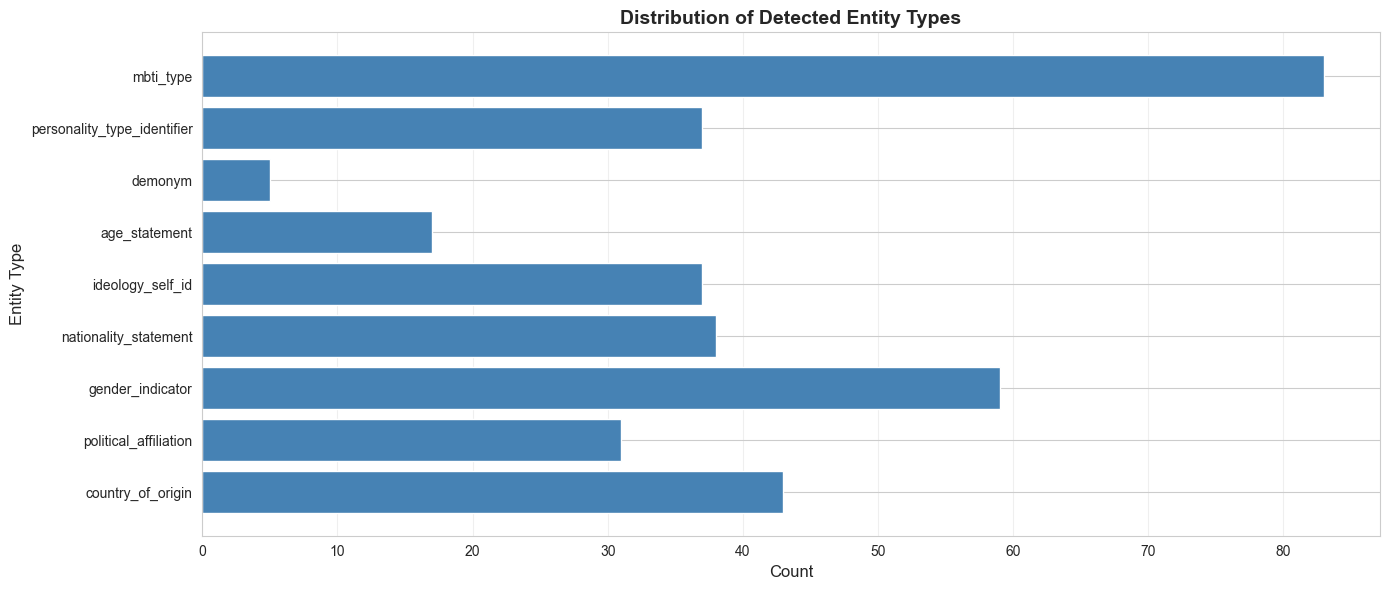


Most common entity types:
  mbti_type                   : 83
  gender_indicator            : 59
  country_of_origin           : 43
  nationality_statement       : 38
  ideology_self_id            : 37
  personality_type_identifier : 37
  political_affiliation       : 31
  age_statement               : 17


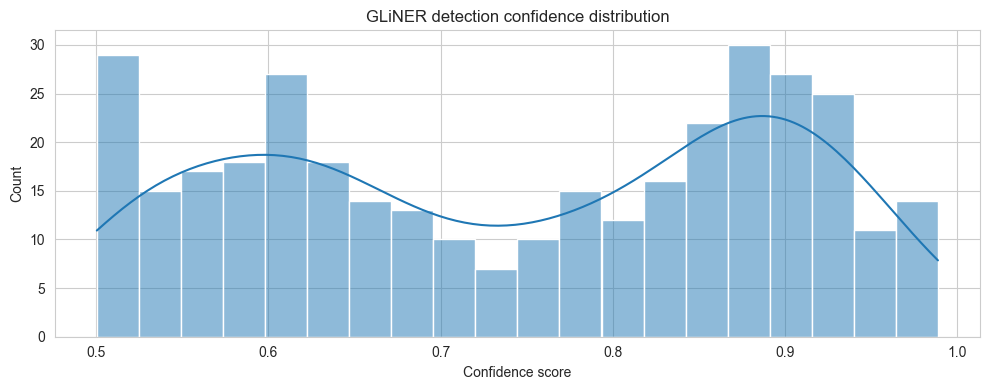


Span character-length summary:
count    350.000000
mean       6.388571
std        3.881908
min        1.000000
50%        5.000000
90%       11.000000
95%       15.000000
max       26.000000


In [ ]:
# Collect all detected labels + scores
all_labels = []
all_scores = []
all_span_char_lens = []
post_with_entity = {}  # Map post_id to detected entities

for i, entities in enumerate(entities_batch):
    for entity in entities:
        all_labels.append(entity['label'])
        all_scores.append(float(entity.get('score', 0.0)))
        span_len = int(entity.get('end', 0)) - int(entity.get('start', 0))
        all_span_char_lens.append(span_len)
        
        # Track which posts have which entity types
        if post_ids[i] not in post_with_entity:
            post_with_entity[post_ids[i]] = []
        post_with_entity[post_ids[i]].append(entity['label'])

label_counts = Counter(all_labels)

# Plot label distribution
fig, ax = plt.subplots(figsize=(14, 6))
labels_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels = [l[0] for l in labels_sorted]
counts = [l[1] for l in labels_sorted]

ax.barh(labels, counts, color='steelblue')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Entity Type', fontsize=12)
ax.set_title('Distribution of Detected Entity Types (sorted by frequency)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
print("ENTITY DETECTION STATISTICS")
print("=" * 80)
print(f"\nTotal unique entity types detected: {len(label_counts)}")
print(f"Total entity spans detected: {sum(counts)}")
print("\nTop 10 most common entity types:")
for label, count in label_counts.most_common(10):
    pct = 100 * count / sum(counts)
    print(f"  {label:30s}: {count:4d} ({pct:5.1f}%)")
print("=" * 80)

# Confidence histogram
if all_scores:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(all_scores, bins=30, alpha=0.8, color='steelblue', edgecolor='black')
    axes[0].axvline(detector.confidence_threshold, color='red', linestyle='--', 
                    linewidth=2, label=f'Threshold={detector.confidence_threshold:.2f}')
    axes[0].set_title("GLiNER Detection Confidence Distribution", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Confidence Score", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Confidence by top entity types
    top_labels = [l[0] for l in labels_sorted[:8]]
    scores_by_label = {label: [] for label in top_labels}
    
    for i, entities in enumerate(entities_batch):
        for entity in entities:
            if entity['label'] in scores_by_label:
                scores_by_label[entity['label']].append(entity.get('score', 0.0))
    
    bp = axes[1].boxplot(
        [scores_by_label[label] for label in top_labels if scores_by_label[label]],
        labels=[label for label in top_labels if scores_by_label[label]],
        patch_artist=True,
    )
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    axes[1].set_title("Confidence Distribution by Entity Type (Top 8)", fontsize=13, fontweight='bold')
    axes[1].set_ylabel("Confidence Score", fontsize=12)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Span-length summary and distribution
if all_span_char_lens:
    s = pd.Series(all_span_char_lens)
    print("\n" + "=" * 80)
    print("SPAN CHARACTER-LENGTH STATISTICS")
    print("=" * 80)
    print(s.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).to_string())
    print("=" * 80)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(all_span_char_lens, bins=50, alpha=0.8, color='forestgreen', edgecolor='black')
    ax.axvline(s.median(), color='red', linestyle='--', linewidth=2, 
               label=f'Median={s.median():.0f}')
    ax.axvline(s.quantile(0.95), color='orange', linestyle='--', linewidth=2,
               label=f'95th percentile={s.quantile(0.95):.0f}')
    ax.set_xlabel('Span Length (characters)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Distribution of Detected Span Lengths', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5. Calculate Explicit Recall

Compare GLiNER detections against simple regex baseline to measure recall on explicit patterns.

In [ ]:
# Calculate Explicit Recall (library implementation)
reference_patterns = detector.taxonomy.get_reference_patterns()
recall = compute_explicit_recall(posts, entities_batch, reference_patterns)

print("=" * 80)
print("EXPLICIT RECALL (GLiNER vs Regex Reference)")
print("=" * 80)

overall = recall.get("overall")
if overall is not None:
    print(f"\nOverall Recall: {overall:.1%}")
else:
    print("\nOverall Recall: N/A (no reference spans found)")

per_label = recall.get("per_label", {})
if per_label:
    print("\nPer-Label Recall:")
    per_label_list = []
    for label, r in sorted(per_label.items(), key=lambda x: x[1] if x[1] is not None else -1, reverse=True):
        if r is None:
            continue
        per_label_list.append({'label': label, 'recall': r})
        print(f"  {label:30s}: {r:.1%}")
    
    # Create dataframe and plot
    if per_label_list:
        recall_df = pd.DataFrame(per_label_list)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = ['forestgreen' if r >= 0.9 else 'orange' if r >= 0.7 else 'coral' 
                  for r in recall_df['recall']]
        ax.barh(recall_df['label'], recall_df['recall'], color=colors, alpha=0.8)
        ax.axvline(0.95, color='red', linestyle='--', linewidth=2, 
                   label=f"Target threshold (95%)")
        ax.set_xlabel('Recall', fontsize=12)
        ax.set_ylabel('Entity Type', fontsize=12)
        ax.set_title('Explicit Recall by Entity Type', fontsize=14, fontweight='bold')
        ax.set_xlim(0, 1.0)
        ax.legend()
        ax.grid(alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

print("\n" + "=" * 80)
print("DETECTION COUNTS")
print("=" * 80)
print(f"  Total reference spans:    {recall.get('total_reference_spans', 0)}")
print(f"  Matched reference spans:  {recall.get('matched_reference_spans', 0)}")
print(f"  Total GLiNER detections:  {sum(len(e) for e in entities_batch)}")
print("=" * 80)

# Check against threshold
threshold = float(pipeline.config["gliner"]["explicit_recall_threshold"])
print(f"\nTarget explicit recall threshold: {threshold:.1%}")
if overall is not None:
    if overall >= threshold:
        print(f"✓ Target achieved: {overall:.1%} >= {threshold:.1%}")
    else:
        print(f"✗ Target not met: {overall:.1%} < {threshold:.1%}")
else:
    print("⚠ Cannot evaluate: no reference spans found")
print("=" * 80)


Explicit Recall (GLiNER vs Regex Reference):

Overall: 8.8%

Per-label recall:
  age_statement               : 12.5%
  country_of_origin           : 25.0%
  gender_indicator            : 0.0%
  mbti_type                   : 30.4%
  nationality_statement       : 0.6%

Counts:
  total_reference_spans:   866
  matched_reference_spans: 76


In [ ]:
# Analyze masking coverage
mask_stats = []

for i, (post, entities) in enumerate(zip(posts, entities_batch)):
    post_len = len(post)
    total_masked_chars = sum(e.get('end', 0) - e.get('start', 0) for e in entities)
    mask_coverage = total_masked_chars / post_len if post_len > 0 else 0.0
    
    mask_stats.append({
        'post_id': post_ids[i],
        'post_length': post_len,
        'n_entities': len(entities),
        'masked_chars': total_masked_chars,
        'mask_coverage': mask_coverage,
    })

mask_df = pd.DataFrame(mask_stats)

print("=" * 80)
print("MASKING COVERAGE STATISTICS")
print("=" * 80)
print(f"Total posts analyzed: {len(mask_df)}")
print(f"Posts with entities:  {(mask_df['n_entities'] > 0).sum()} ({100 * (mask_df['n_entities'] > 0).sum() / len(mask_df):.1f}%)")
print(f"\nMask coverage statistics (for posts with entities):")
masked_posts = mask_df[mask_df['n_entities'] > 0]
if len(masked_posts) > 0:
    print(masked_posts['mask_coverage'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())
print("=" * 80)

# Plot masking coverage distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of mask coverage
axes[0, 0].hist(mask_df['mask_coverage'], bins=30, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Mask Coverage (fraction of post)', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_title('Distribution of Mask Coverage', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Plot 2: Number of entities per post
axes[0, 1].hist(mask_df['n_entities'], bins=range(0, max(mask_df['n_entities'])+2), 
                alpha=0.8, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Number of Entities Detected', fontsize=11)
axes[0, 1].set_ylabel('Count', fontsize=11)
axes[0, 1].set_title('Distribution of Entity Count per Post', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Scatter - post length vs masked chars
axes[1, 0].scatter(mask_df['post_length'], mask_df['masked_chars'], 
                   alpha=0.5, s=30, color='forestgreen')
axes[1, 0].set_xlabel('Post Length (characters)', fontsize=11)
axes[1, 0].set_ylabel('Masked Characters', fontsize=11)
axes[1, 0].set_title('Post Length vs Masked Content', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Scatter - entities vs mask coverage
masked_only = mask_df[mask_df['n_entities'] > 0]
axes[1, 1].scatter(masked_only['n_entities'], masked_only['mask_coverage'], 
                   alpha=0.5, s=30, color='purple')
axes[1, 1].set_xlabel('Number of Entities', fontsize=11)
axes[1, 1].set_ylabel('Mask Coverage', fontsize=11)
axes[1, 1].set_title('Entity Count vs Mask Coverage', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify posts with highest masking coverage
top_masked = mask_df.nlargest(3, 'mask_coverage')
print("\n" + "=" * 80)
print("TOP 3 POSTS BY MASK COVERAGE")
print("=" * 80)
for idx, row in top_masked.iterrows():
    print(f"\nPost {idx}: {row['mask_coverage']:.1%} masked ({row['n_entities']} entities)")
    print(f"Original length: {row['post_length']} chars")
    print(f"Sample: {posts[idx][:200]}...")
print("=" * 80)


## 7. Masking Coverage Analysis

Analyze what percentage of text gets masked and masking density patterns.

In [ ]:
# Build co-occurrence matrix for top entity types
top_n = 10
top_entity_types = [l[0] for l in label_counts.most_common(top_n)]

# Create binary matrix: [n_posts x n_entity_types]
post_entity_matrix = []
posts_with_detection = []

for i, entities in enumerate(entities_batch):
    if entities:  # Only consider posts with at least one detection
        entity_types_in_post = set(e['label'] for e in entities)
        row = [1 if et in entity_types_in_post else 0 for et in top_entity_types]
        post_entity_matrix.append(row)
        posts_with_detection.append(i)

if post_entity_matrix:
    post_entity_matrix = np.array(post_entity_matrix)
    
    # Compute co-occurrence matrix: how often entity types appear together
    cooccurrence = post_entity_matrix.T @ post_entity_matrix
    
    # Normalize by marginals to get co-occurrence ratio
    entity_counts = post_entity_matrix.sum(axis=0)
    cooccurrence_norm = np.zeros_like(cooccurrence, dtype=float)
    for i in range(len(top_entity_types)):
        for j in range(len(top_entity_types)):
            if i == j:
                cooccurrence_norm[i, j] = 1.0
            elif entity_counts[i] > 0:
                cooccurrence_norm[i, j] = cooccurrence[i, j] / entity_counts[i]
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cooccurrence_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Co-occurrence Probability', fontsize=12)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(top_entity_types)))
    ax.set_yticks(np.arange(len(top_entity_types)))
    ax.set_xticklabels(top_entity_types, rotation=45, ha='right')
    ax.set_yticklabels(top_entity_types)
    
    # Add text annotations
    for i in range(len(top_entity_types)):
        for j in range(len(top_entity_types)):
            if i != j:  # Skip diagonal
                text = ax.text(j, i, f'{cooccurrence_norm[i, j]:.2f}',
                             ha="center", va="center", color="black" if cooccurrence_norm[i, j] < 0.5 else "white",
                             fontsize=8)
    
    ax.set_title(f'Entity Type Co-occurrence Matrix (Top {top_n})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Entity Type', fontsize=12)
    ax.set_ylabel('Entity Type', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("=" * 80)
    print("CO-OCCURRENCE INTERPRETATION")
    print("=" * 80)
    print("Each cell [i,j] shows: P(entity_j appears | entity_i appears)")
    print("High values indicate entity types that frequently appear together.")
    print("=" * 80)
else:
    print("No co-occurrence data available (no posts with detections)")


## 6. Entity Co-occurrence Analysis

Analyze which entity types tend to co-occur in the same posts.